In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
import os
import OptimalBattery.global_config as gcf
import OptimalBattery.util as ut



In [2]:
data_path = gcf.data_path
data_path

'/Volumes/diedrichsen_data$/data'

# build transition matrix for visualization only...

In [3]:
dat_file = df = pd.read_csv(f"{data_path}/Cerebellum/super_cerebellum/sc1/data/s16/sc1_s16.dat", delim_whitespace=True, header=0)
filtered_dat = dat_file[dat_file["runNum"] >= 51]

In [4]:
# collect (prev_task, curr_task) pairs across runs
pairs = []
for _, g in filtered_dat.groupby("runNum"):
    names = g["taskName"].tolist()
    pairs.append(("start",names[0]))  # start of run
    pairs.extend(zip(names[:-1], names[1:]))          # immediate transitions only

length = len(pairs)
print(f"Total number of transitions: {length}")

Total number of transitions: 272


In [5]:
# Build counts matrix
trans_counts = pd.crosstab(
    pd.Series([a for a, b in pairs], name="prev"),
    pd.Series([b for a, b in pairs], name="curr"),
    dropna=False
).fillna(0).astype(int)

In [6]:
tasks = sorted(filtered_dat["taskName"].unique())
trans_counts = trans_counts.reindex(
    index=["start"] + tasks,   # force start to top
    columns=tasks,            
    fill_value=0
)


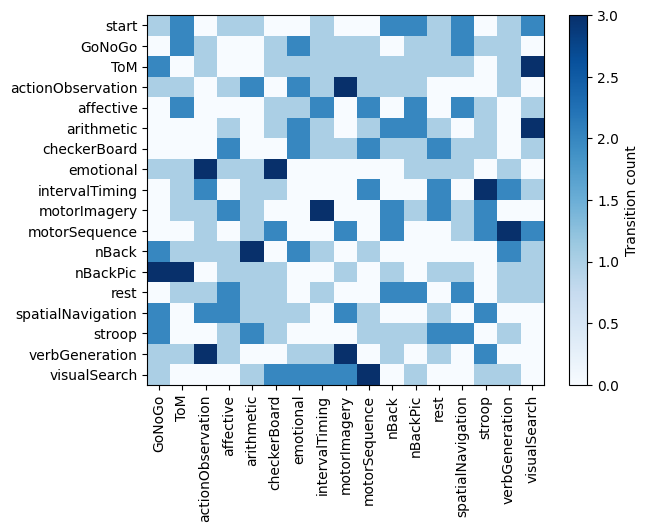

In [7]:
im = plt.imshow(trans_counts, cmap="Blues", aspect="auto")
plt.xticks(range(len(trans_counts.columns)), trans_counts.columns, rotation=90)
plt.yticks(range(len(trans_counts.index)), trans_counts.index)
plt.colorbar(im, label="Transition count")
plt.show()

the max transition repeat is 3. And you get about 3/4 of the possible transitions.

# Variance decomp (carry over)

In [19]:
def make_prev_cond(cond_vec, part_vec):
    """
    Make a vector of previous global condition IDs (per run).
    First task in each run gets -1.
    """
    prev_vec = np.full_like(cond_vec, -1)  # fill with -1
    for t in range(1, len(cond_vec)):
        if part_vec[t] == part_vec[t-1]:       # same run → use previous cond
            prev_vec[t] = cond_vec[t-1]
        # else → leave as -1 (first task in run)
    return prev_vec
 
def decompose_carryover(data,info,cond_vec,part_vec, include_start=True, criterion="runs"):
    """
    Decompose data into task, systematic carryover, subject, noise (idosyncratic carryover + movement noise)
    Params:
    data : np.ndarray
        Array of shape (n_subjects, n_tasks, n_voxels)
    info : pd.DataFrame
        MDTB info dataframe with columns ["run", "task_name", "task_num", ...]
    cond_vec : np.ndarray
        Array of shape (n_tasks,) with global condition IDs (task_num)
    part_vec : np.ndarray
        Array of shape (n_tasks,) with partition/run IDs
    Returns
    -------
    """

    # make a vector of previous conditions (-1 for first task in run)
    prev_vec = make_prev_cond(cond_vec, part_vec)

    # filter out first tasks if not including start
    if not include_start:
        valid_mask = prev_vec != -1
        info = info.loc[valid_mask].reset_index(drop=True)
        cond_vec = cond_vec[valid_mask]
        part_vec = part_vec[valid_mask]
        prev_vec = prev_vec[valid_mask]
        data = data[:, valid_mask, :]

    n_subj, n_regs, n_vox = data.shape
    # make design vectors
    subj_vec = np.repeat(np.arange(n_subj), n_regs)
    curr_vec = np.tile(cond_vec, n_subj)
    prev_vec = np.tile(prev_vec, n_subj)
    run_vec = np.tile(part_vec, n_subj)

    # Compute inner product matrix
    Y = data.reshape(n_subj*n_regs, n_vox)
    YY = Y @ Y.T

    # Create masks for different comparison types
    same_subj   = subj_vec[:, None] == subj_vec[None, :]
    same_run    = run_vec[:, None] == run_vec[None, :]
    same_curr   = curr_vec[:, None] == curr_vec[None, :]
    same_prev   = prev_vec[:, None] == prev_vec[None, :]

    # Group/task (cross-subject, any prev) 
    mask_group = ~same_subj & same_curr # sigma(group)

    # Subject-specific
    mask_within_acrossruns = same_subj & ~same_run & same_curr # sigma (task) + sigma (Carry) + sigma (subject)
    mask_within_samerun  = same_subj & same_run & same_curr # sigma (task) + sigma (carry) + sigma (subject) +sigma (noise) - this is the variance of the betas

    # Carry-over (cross-subject, same task, same/diff runs) (the sum of carry and non-carry is the group effect)
    mask_between_samerun    = ~same_subj & same_curr & same_run # sigma(task) + sigma (carry)
    mask_between_acrossruns = ~same_subj & same_curr & ~same_run # sigma (task)

    # Carry-over (cross-subject, same task, same/diff runs) (the sum of carry and non-carry is the group effect)
    mask_between_sameprev    = ~same_subj & same_curr & ~same_run & same_prev # sigma(task) + sigma (carry)
    mask_between_nsameprev = ~same_subj & same_curr & ~same_run & ~same_prev # sigma (task)

    # Compute mean values for each component
    cov_group   = np.nanmean(YY[mask_group])
    cov_within_acrossruns = np.nanmean(YY[mask_within_acrossruns])
    cov_within_samerun    = np.nanmean(YY[mask_within_samerun])
    cov_between_acrossruns   = np.nanmean(YY[mask_between_acrossruns])
    cov_between_samerun= np.nanmean(YY[mask_between_samerun])
    cov_between_nsameprev   = np.nanmean(YY[mask_between_nsameprev])
    cov_between_sameprev= np.nanmean(YY[mask_between_sameprev])

    if criterion == "runs":
        # Decompose variance components (using same / different runs)
        v_t = cov_between_acrossruns # reliable task  variance 
        v_c = cov_between_samerun - cov_between_acrossruns # carry-over variance
        v_s = cov_within_acrossruns - cov_between_acrossruns
    
    if criterion == "prev":
        # Decompose variance components (using same / different previous tasks)
        v_t = cov_between_nsameprev # reliable task  variance 
        v_c = cov_between_sameprev - cov_between_nsameprev # carry-over variance
        v_s = cov_within_acrossruns - cov_between_nsameprev

    # Express thew proportions as fraction of the total reliable variance (within subject)
    total = v_s  + v_c + v_t
    print(f"proportions: task(non-carry): {v_t / total:.3f}, carry: {v_c / total:.3f}, subject: {v_s / total:.3f}")

    #Subject-specific carry-over (within-subject, same task)
    v_c_per_subj = np.empty(n_subj)
    for s in range(n_subj):
        row = (subj_vec == s)
        # pairs where one side is subject s and the other is not s
        edges_s = (row[:, None] & ~row[None, :]) | (~row[:, None] & row[None, :])

        m_c  = mask_between_samerun    & edges_s
        m_nc = mask_between_acrossruns & edges_s

        v_c_per_subj[s] = np.nanmean(YY[m_c]) - np.nanmean(YY[m_nc])

    return v_c_per_subj

# Cerebellum

In [20]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)

# needed to map runs from the old(data files) to the new(info_mdtb_1_run)
run_map = {51: 1,52: 2,53: 3,54: 4,55: 5,56: 6,57: 7,58: 8,59: 9,60: 10,61: 11,62: 12,63: 13,64: 14,65: 15,66: 16,}

data_mdtb_s1_run_reordered, info_mdtb_1_run_reordered = ut.reorder_mdtb(
    data_mdtb_s1_run,
    info_mdtb_1_run,
    filtered_dat,
    run_map= run_map
)

cond_vec = info_mdtb_1_run_reordered["task_num"].values   # global condition ID
part_vec  = info_mdtb_1_run_reordered["run"].values  


In [21]:
# Estimate carry-over using the same / different runs across subjects
print("Excluding start of run")
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False, criterion="runs"
)

print("Including start of run")


subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True, criterion="runs"
)


Excluding start of run
proportions: task(non-carry): 0.256, carry: 0.054, subject: 0.690
Including start of run
proportions: task(non-carry): 0.257, carry: 0.053, subject: 0.691


In [22]:
# Estimate carry-over using the same / different precvious task across subjects
print("Excluding start of run")
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False, criterion="prev"
)

print("Including start of run")


subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True, criterion="prev"
)

Excluding start of run
proportions: task(non-carry): 0.264, carry: 0.019, subject: 0.717
Including start of run
proportions: task(non-carry): 0.265, carry: 0.019, subject: 0.716


In [24]:
from scipy.stats import ttest_1samp,ttest_rel
t, p = ttest_1samp(subject_carryover, 0.0)
print(f"Subject carry-over t={t:.3f}, p={p:.3e}")

t_start, p_start = ttest_1samp(subject_carryover_start, 0.0)
print(f"Subject carry-over (including start) t={t_start:.3f}, p={p_start:.3e}")

Subject carry-over t=6.731, p=7.252e-07
Subject carry-over (including start) t=6.504, p=1.230e-06


In [25]:
from Functional_Fusion.reliability import decompose_subj_group
c = decompose_subj_group(
    data_mdtb_s1_run_reordered,
    cond_vec,
    part_vec
)


In [26]:
total = np.sum(c)
print(f"group {c[:,0].item()/total:.3f}, subject {c[:,1].item()/total:.3f}, noise {c[:,2].item()/total:.3f}")

group 0.025, subject 0.067, noise 0.907


# Cortex

In [23]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)

# needed to map runs from the old(data files) to the new(info_mdtb_1_run)
run_map = {51: 1,52: 2,53: 3,54: 4,55: 5,56: 6,57: 7,58: 8,59: 9,60: 10,61: 11,62: 12,63: 13,64: 14,65: 15,66: 16,}

data_mdtb_s1_run_reordered, info_mdtb_1_run_reordered = ut.reorder_mdtb(
    data_mdtb_s1_run,
    info_mdtb_1_run,
    filtered_dat,
    run_map= run_map
)

cond_vec = info_mdtb_1_run_reordered["task_num"].values   # global condition ID
part_vec  = info_mdtb_1_run_reordered["run"].values  


In [ ]:
# Estimate carry-over using the same / different runs across subjects
print("Excluding start of run")
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False, criterion="runs"
)

print("Including start of run")

subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True, criterion="runs")


Excluding start of run
proportions: task(non-carry): 0.401, carry: 0.038, subject: 0.561
Including start of run


TypeError: decompose_carryover() got an unexpected keyword argument 'citerion'

In [ ]:
# Estimate carry-over using the different runs, but same or different previous task across subjects
print("Excluding start of run")
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False, criterion="prev"
)

print("Including start of run")

subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True,citerion="prev"
)

In [29]:
from scipy.stats import ttest_1samp,ttest_rel
t, p = ttest_1samp(subject_carryover, 0.0)
print(f"Subject carry-over t={t:.3f}, p={p:.3e}")

t_start, p_start = ttest_1samp(subject_carryover_start, 0.0)
print(f"Subject carry-over (including start) t={t_start:.3f}, p={p_start:.3e}")

Subject carry-over t=12.351, p=1.240e-11
Subject carry-over (including start) t=13.366, p=2.496e-12


In [30]:
from Functional_Fusion.reliability import decompose_subj_group
c = decompose_subj_group(
    data_mdtb_s1_run_reordered,
    cond_vec,
    part_vec
)

total = np.sum(c)
print(f"group {c[:,0].item()/total:.3f}, subject {c[:,1].item()/total:.3f}, noise {c[:,2].item()/total:.3f}")

group 0.128, subject 0.178, noise 0.694
